#S4 - Linear Regression & Statistical Modeling
---------

Whether you are MBA, MSBA, IBear or a different program, you will have had some statistics classes in your degree, using either R or Radiant. Here, I will show you how to run similar analysis in python. 

However, this will be a brief introduction into how you can perform such analysis using python. Obviously, there are so many techniques that you can utilize for different problems, that we cannot possibly go through them all. 

I will focus on: 

- Implmenting Linear regression in Python

- Implementing Clustering 


#S4.1 - Loading Relevant Python Packages

--- 

When begining with statistical analysis (like most other things) you have to have a clear plan in terms of what you want to do and what type fo analysis is a appropriate. 

We are going to use two packages: 

- Scikit-learn [Easy to use Statustical modeling & Machine Learning Package]
- Statsmodels [Easy to use / interpret econometrics - regression package]

Sklearn has a very nice flow chart (below) describing what statistical method you should use for which type of problem. 




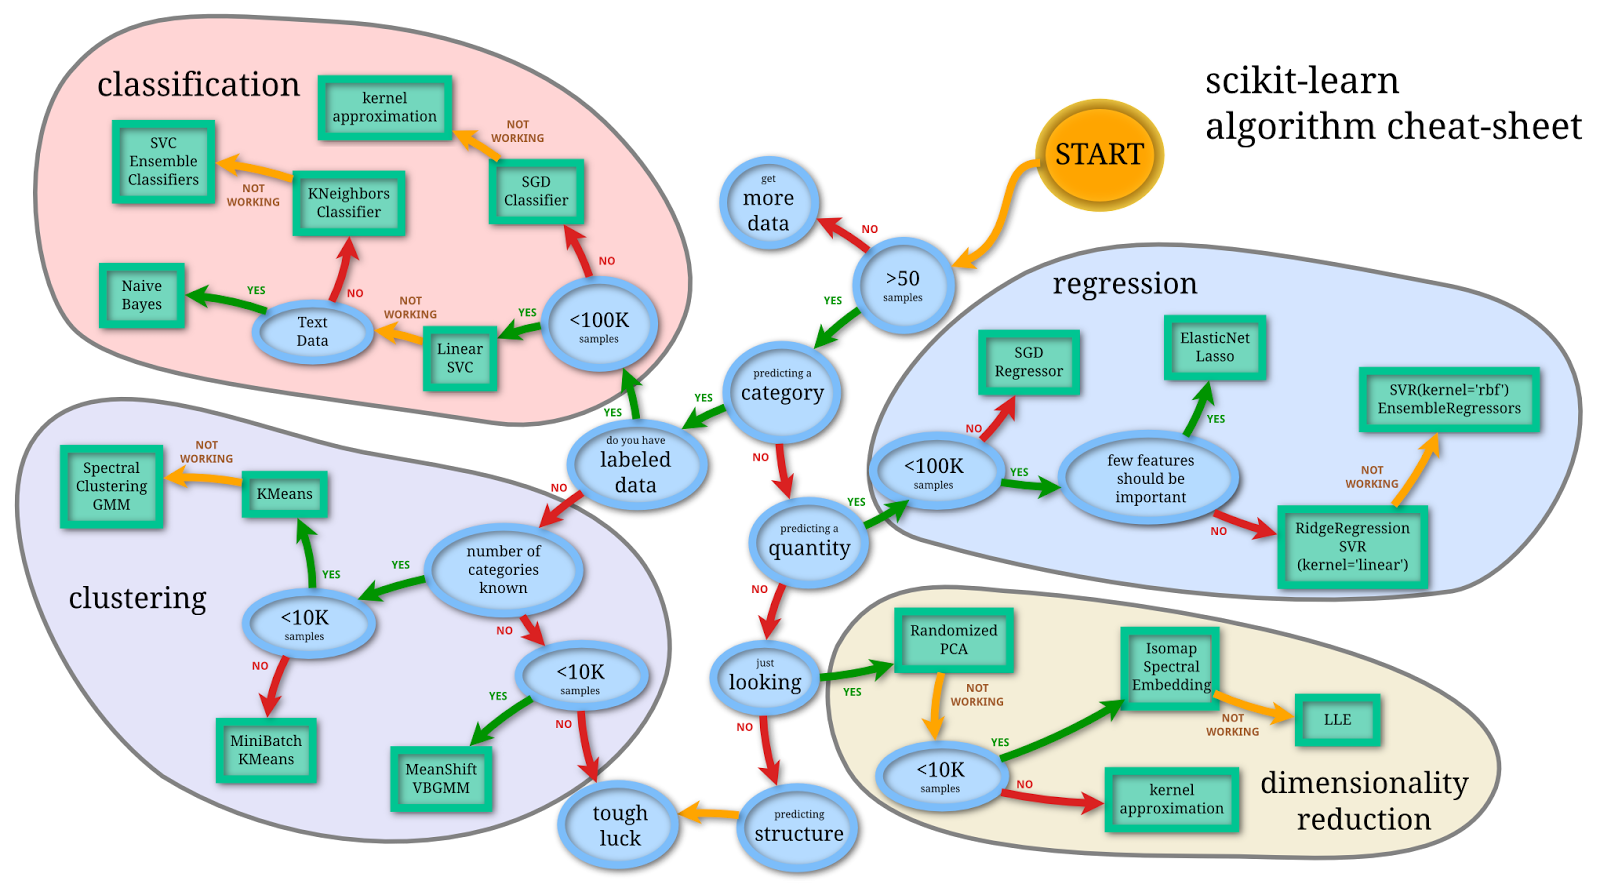

Becuase both SkLearn and statsmdoels are so large (meaning they have so many built in functions) we will only load these in once we need them. 

In [ ]:
# Let's just load in the data so that we can get started with the analysis # 

from google.colab import drive       

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os 

os.chdir("./drive/MyDrive/Teaching/DSO 574/Notebooks for Python Workshops/Data Files")

In [ ]:
import pandas as pd

data = pd.read_csv("./LA2020listings.csv")

In [ ]:
# Let's select only the data we want (see the previous workshop if these commands are unclear)# 

workingdata = data.loc[ (data['room_type'] == 'Entire home/apt') | (data['room_type'] == 'Private Room')]

workingdata = workingdata.loc[(workingdata['neighbourhood'] == 'Santa Monica')|(workingdata['neighbourhood'] == 'Venice')|(workingdata['neighbourhood'] == 'Downtown')]


#S4.2 - Simple (One Variable ) Linear Regression with Visual Tools

--- 

When discussing linear regression, we are refering to orinary least squares (OLS) regression. You would have had an outcome (Y variable, dependent variable, response variable), and a explanatory (x variable, independent variable). 

The goal is to estimat a function of the form: 

y = a + Bx 

where y and x are the data we are providing, and a & B are coefficients which we are attempting to estimate. Those coefficients describe the relationship between x and y. 

In [ ]:
# let's remind ourselves of th ecolumns in the data # 

data.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

Suppose that we want to understand how the characteristics of a listing influence the number of bookings (which we interpret as a measure of revenues / success). 

Let's begin with the following very simple model: 

- Y (Outcome) = 'reviews_per_month'
- X1 = 'price'
- X2 = 'room_type'
- X3 = 'neighbourhood'


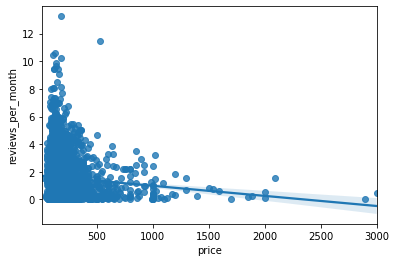

In [ ]:
# Let's first do some simple diagnostic plots of the data -- I will use seaborn for this because it helps to visualize what I am doing # 

import seaborn as sns 

# I will use regplot which plots the data as well as the regression line. 

sns.regplot(data = workingdata, 
                x = 'price',
                y = 'reviews_per_month')


From this graph we can see the range of values (Reviews per month seems to vary between 0 and 13). On the other hand, price seems to vary between 0 and 3000 dollars are night, but the majority of values are between 0 and 500 per night. 

The problem here is that because of these outliers (the data is not evenly distributed across the x axis (0 - 3000) the regression line may not be a correct representation of the true relationship of x and y. There are various ways to deal with this. You can remove outliers, or you can log transform the data. I will demonstrate both approaches below. 

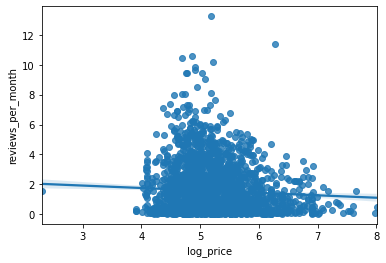

In [ ]:
# Log Transforming the Price (X) variable # 

import numpy as np 

workingdata['log_price'] = np.log(workingdata['price'])

sns.regplot(data = workingdata, 
                x = 'log_price',
                y = 'reviews_per_month')


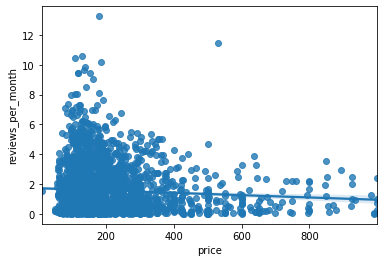

In [ ]:
# Selecting only observations below 1000 # 

workingdata_below1000 = workingdata.loc[workingdata['price']<1000]

sns.regplot(data = workingdata_below1000, 
                x = 'price',
                y = 'reviews_per_month')


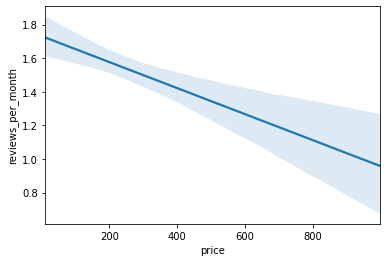

In [ ]:
# If you want to see the line more clearly without being obstructed by the variables, you can tell regplot to remove the scatterplot by saying Scatter = False #


sns.regplot(data = workingdata_below1000, 
                x = 'price',
                y = 'reviews_per_month', 
                scatter = False)


The light blue lines represent the confidence intervals. The default is 95% confidence intervals. However, you can change these with the CI function. 
For instance if you want to remove these set CI = 0, or put CI = 99 if you want 99% Confidence Intervals. 

# S4.3  - Simple (One Variable) Linear Regression with R Style Output
---

You may be more acustomed to seeing regression results in a table. This is what I refer to as an "R Style" output. This format is often more useful as it provides a clear estimate of the slope (B) and intercept (a) of the model as well as confidence intervals for those estimates. 

To do this, we will use the statsmodels package as it provides what is usually a very familiar interface. You can see the documentation here: https://www.statsmodels.org/stable/index.html 

Since we are running OLS, here you have a nice elaboration of how to use this model: https://www.statsmodels.org/stable/example_formulas.html 

In [ ]:
# Import the Statsmodels Package #

import statsmodels.formula.api as smf


/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


 The synax to run a regression is as follows :

 smf.ols('Y Variable ~ X Variable ', data = df)

In [ ]:
# To run the regression in our particular case, we save this result as mod [i'm following the syntax in the documentation so you can look for more details there as well]

mod = smf.ols(formula='reviews_per_month ~ price', data=workingdata_below1000)


In [ ]:
# To fit the model and output the results we run the following. 

res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:      reviews_per_month   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     9.656
Date:                Sat, 06 Feb 2021   Prob (F-statistic):            0.00191
Time:                        04:35:24   Log-Likelihood:                -4458.4
No. Observations:                2291   AIC:                             8921.
Df Residuals:                    2289   BIC:                             8932.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.7307      0.062     27.998      0.0

This is a lot of information, so I will highlight the key information in the regression output. 

- **R Squared (Upper Right):** This describes how well the model (in our case the line) fits the data. This value is low (close to zero rather than to one) but that is to be expected given the way the data looks above (the line does not pass close to all of the values in the scatter plot). This does not mean that we have to abandon the model. We just have to be aware that our regression model is describing average values, and that the actual observations vary considerably. 
- **No. Observations:** This tells us the number of observations in the data. This is something to look at as sometimes you can mispecify the model and then it looses some observations which can greatly impact your results. 
- **Intercept:** This is the constant (a) value in our model. In the linear graphs above, this is the point where the line intercepts the x axis (the value of y where x = 0). *You can interpret the **coef** as the average number of reviews per month if the price was zero. In this case that value is 1.73*
- **price:** This tells us how much a shift in the price influences the manitude of the outcome variable. This represents the slope of the line in the figures above. *You can interpret the **coef** as how much the average number of reviews decreases with an one unit increase in price. So for example, one dollar more in price coresponds to 0.0008 reviews fewer per month. That is not always super meaningful, so its more useful to think about how much an $100 dollar per night increase impacts the number of reviews (ie. 100*0.0008 = 0.08 decrease). The negative sign indicates a decrease.

The columns to the right of coef, specifically std_err, t, P>t, etc. all describe the statistical significance of this result. What that means in very coarse / practical terms is with what confidence can we conclude that there is in fact a relationship between *price* and *reviews_per_month*. To put this annother way, it means to what extent are we confident that coef is different from zero (as a zero coefficient would corespond to no-relationship). 

The coef and standard error are used to calculate the *t statistic* which coresponds to a *p value* (P > t). This signifies the level of confidence (how confident are we that the value is differnet from zero). So for example if p < t == 0.002 means that we are more than 99% confident that coef is not equal to zero [ 99.8 = 100*(1 - 0.002) which is above the common 99% threshold].


# S4.4  - Multiple Linear Regression with R Style Output
---

The real power of regression is that it allows you to consider multiple variables at once. Here we will begin to consider a few more variables at once. That is diffiult to do visually, but we can do it with the "R_style regression output"



### S4.4.1 - Multiple Continuous Variables 

One important thing to consider is that price is numeric and continous (it is in a range between 0 and 3000). This is important because it directly influences how we introduce this in a regression. These types of variables, we can simply add in to a regression. 

Along with *price*, here we will include the *minimum_nights* as an additional variable. This can potentially control (account) for other factors that may be influencing the relationship between price and the number_of_reviews. 


In [ ]:
# We simply add minimum_nights from our earlier command # 

mod = smf.ols(formula='reviews_per_month ~ price + minimum_nights', data=workingdata_below1000)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:      reviews_per_month   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     96.40
Date:                Sat, 06 Feb 2021   Prob (F-statistic):           6.41e-41
Time:                        04:35:24   Log-Likelihood:                -4370.6
No. Observations:                2291   AIC:                             8747.
Df Residuals:                    2288   BIC:                             8764.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.1895      0.069     31.

We can see that in comparison to the earlier results where the coef for price was -0.008 when we add minimum_nights to the model the coefficient has changed to -0.0011. We can also see that the R-Squared has also increased indicating that this helped explain the variation in our models. We interpret these values in a similar way to what we did before. 

### S4.4.2 - Categorical Variables
--- 

When we described above what we wanted to include in our regression model, we also wanted to include the *neighbourhood* and *room_type* in the regression.
However, those variables are categorical (text or groups), not numerical values that we can include in a regression. 

How to include those in a regression? One approach is to create dummies (0/1 variables which represent one in the cases where a row represents a particular group and zero otherwise. 

Below, to illustrate I will show how this looks if we create a dummy for "Santa Monica" 

In [ ]:
# We use np.where, analogus to if/then in excel to create a 1, 0 variable #

workingdata_below1000['Santa Monica'] = np.where(workingdata_below1000['neighbourhood'] == 'Santa Monica', 1, 0)

# Here, I just use .sample(10) to show a random sample of ten observations.
workingdata_below1000[['number_of_reviews', 'price', 'neighbourhood','Santa Monica']].sample(10)

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


,number_of_reviews,price,neighbourhood,Santa Monica
29465,1,85,Venice,0
7541,202,212,Venice,0
18573,0,99,Venice,0
19671,0,226,Downtown,0
26295,0,500,Venice,0
187,168,279,Venice,0
25175,0,132,Downtown,0
23475,0,200,Venice,0
9224,0,165,Venice,0
8855,7,110,Santa Monica,1


It would be tedious to perform this for each neighbourhood, especially if we have many of these in the data. To address this instead, what we are going to do is to is tell python that we want to treat these variables as categories and to create dummy (1/0) variables in the regression command directly [This is similar to R to those of you that know this]

In [ ]:
# We are going to add C(neighbourhood) to the regression. the C() tells python its a categorical variable. 

mod = smf.ols(formula='reviews_per_month ~ price + minimum_nights + C(neighbourhood)', data=workingdata_below1000)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:      reviews_per_month   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     65.69
Date:                Sat, 06 Feb 2021   Prob (F-statistic):           1.16e-52
Time:                        04:35:24   Log-Likelihood:                -4338.6
No. Observations:                2291   AIC:                             8687.
Df Residuals:                    2286   BIC:                             8716.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

Just like before, we are given a regression output, but we have the categories (groups) indicated by C(neigbourhood). 

Notice that we only have two coeficients (Santa Monica and Venice), while we have three groups (Downtown, Santa Monica and Venice). This is very important. The results reported are for the omitted group (Downtown). The coefficients (coef) for Santa Monica and Venice indicate how much this differs for those locations. 

As an illustration. The intercept of 2.48 indicates that the average reviews_per_month, if price was zero, would be 2.48. In Santa Monica this would be 0.6799 lower, so 2.4843 - 0.6799 = 1.8044 reviews_per_month. 

Notice that we have only a single coeficient for price. Therefore, as price increases our regression results are telling us that reviews_per_month would decrease equally for each neighbourhood. However, suppose that we would like to know if this differs by neighbourhood. We can then use interactions as described below. 


##S4.3.2 - Interactions in Linear Regression 

As mentioned above, we have only a single coeficient for price. Therefore, our results do not provide insights whether the relationship for price differs by neighbourhood. 

For this purpose we use interaction terms. This is basically means multiplying the price and neighbourhood variables. Since the categories are 0/1 variables, this basically means creating variables where price is zero unless it belongs to a particular neighbourhood. To illustrate what this means for our data, I will show you how the data would below. 



In [ ]:

workingdata_below1000['Santa Monica'] = np.where(workingdata_below1000['neighbourhood'] == 'Santa Monica', 1, 0)

workingdata_below1000['Santa Monica Price'] = workingdata_below1000['Santa Monica'] * workingdata_below1000['price']

# Here, I just use .sample(10) to show a random sample of ten observations.
workingdata_below1000[['number_of_reviews', 'price', 'neighbourhood','Santa Monica','Santa Monica Price']].sample(10)

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


,number_of_reviews,price,neighbourhood,Santa Monica,Santa Monica Price
11516,152,149,Venice,0,0
12581,24,175,Downtown,0,0
30951,1,146,Venice,0,0
6528,48,125,Venice,0,0
12416,0,320,Venice,0,0
25281,2,390,Downtown,0,0
13071,8,106,Santa Monica,1,106
19082,15,413,Venice,0,0
20233,0,220,Santa Monica,1,220
25925,13,238,Downtown,0,0


Now, we are going to implement that in a regression using the C() and * to multiply variables (create interactions).

In [ ]:
# We are going to add C(neighbourhood) to the regression. the C() tells python its a categorical variable. 

mod = smf.ols(formula='reviews_per_month ~ price*C(neighbourhood) ', data=workingdata_below1000)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:      reviews_per_month   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     16.21
Date:                Sat, 06 Feb 2021   Prob (F-statistic):           9.65e-16
Time:                        04:35:24   Log-Likelihood:                -4423.3
No. Observations:                2291   AIC:                             8859.
Df Residuals:                    2285   BIC:                             8893.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

Now we have a few new coefficients that represent the interaction terms. 

*   price:C(neighbourhood)[T.Santa Monica]
*   price:C(neighbourhood)[T.Venice] 

As before *price* represents the relationship between price and number_of_reviews for the baseline / omitted group (Downtown). Notice that now the t value for *price* has become smaller, and the p value has increased far above 0.01 (the 99% confidence threshold). Therefore, price is no longer significant suggesting that in downtown price does not influence the number_of_reviews (coef not different from zero).

The two new coefficients (interaction terms) indicate whether the relationship between *price* and *number_of_reviews* is different in Venice and Santa Monica than downtown. The interaction for Venice is significant at the 95% level (0.033), indicating that in venice, a one unit increase in price (one dollar higher price) coresponds to a reduction in the number_of_reviews by 0.0015. 


#4.5 - Other Models in Python

----

There is a variety of other models that researchers may want to use as indicated in the figure at the begining of this document. 

I will only show you clustering as an illustration, and an application that many of you may want to use. However, in realtiy. There are a variety of other applications that you can explore yourselves if interested. 

You can see more details on how clustering is done with sklearn here: 

https://scikit-learn.org/stable/modules/clustering.html

Basically, the intuition can be seen from this figure (copied from that link) and pasted below. Clustering is taking the data and putting it into groups. 


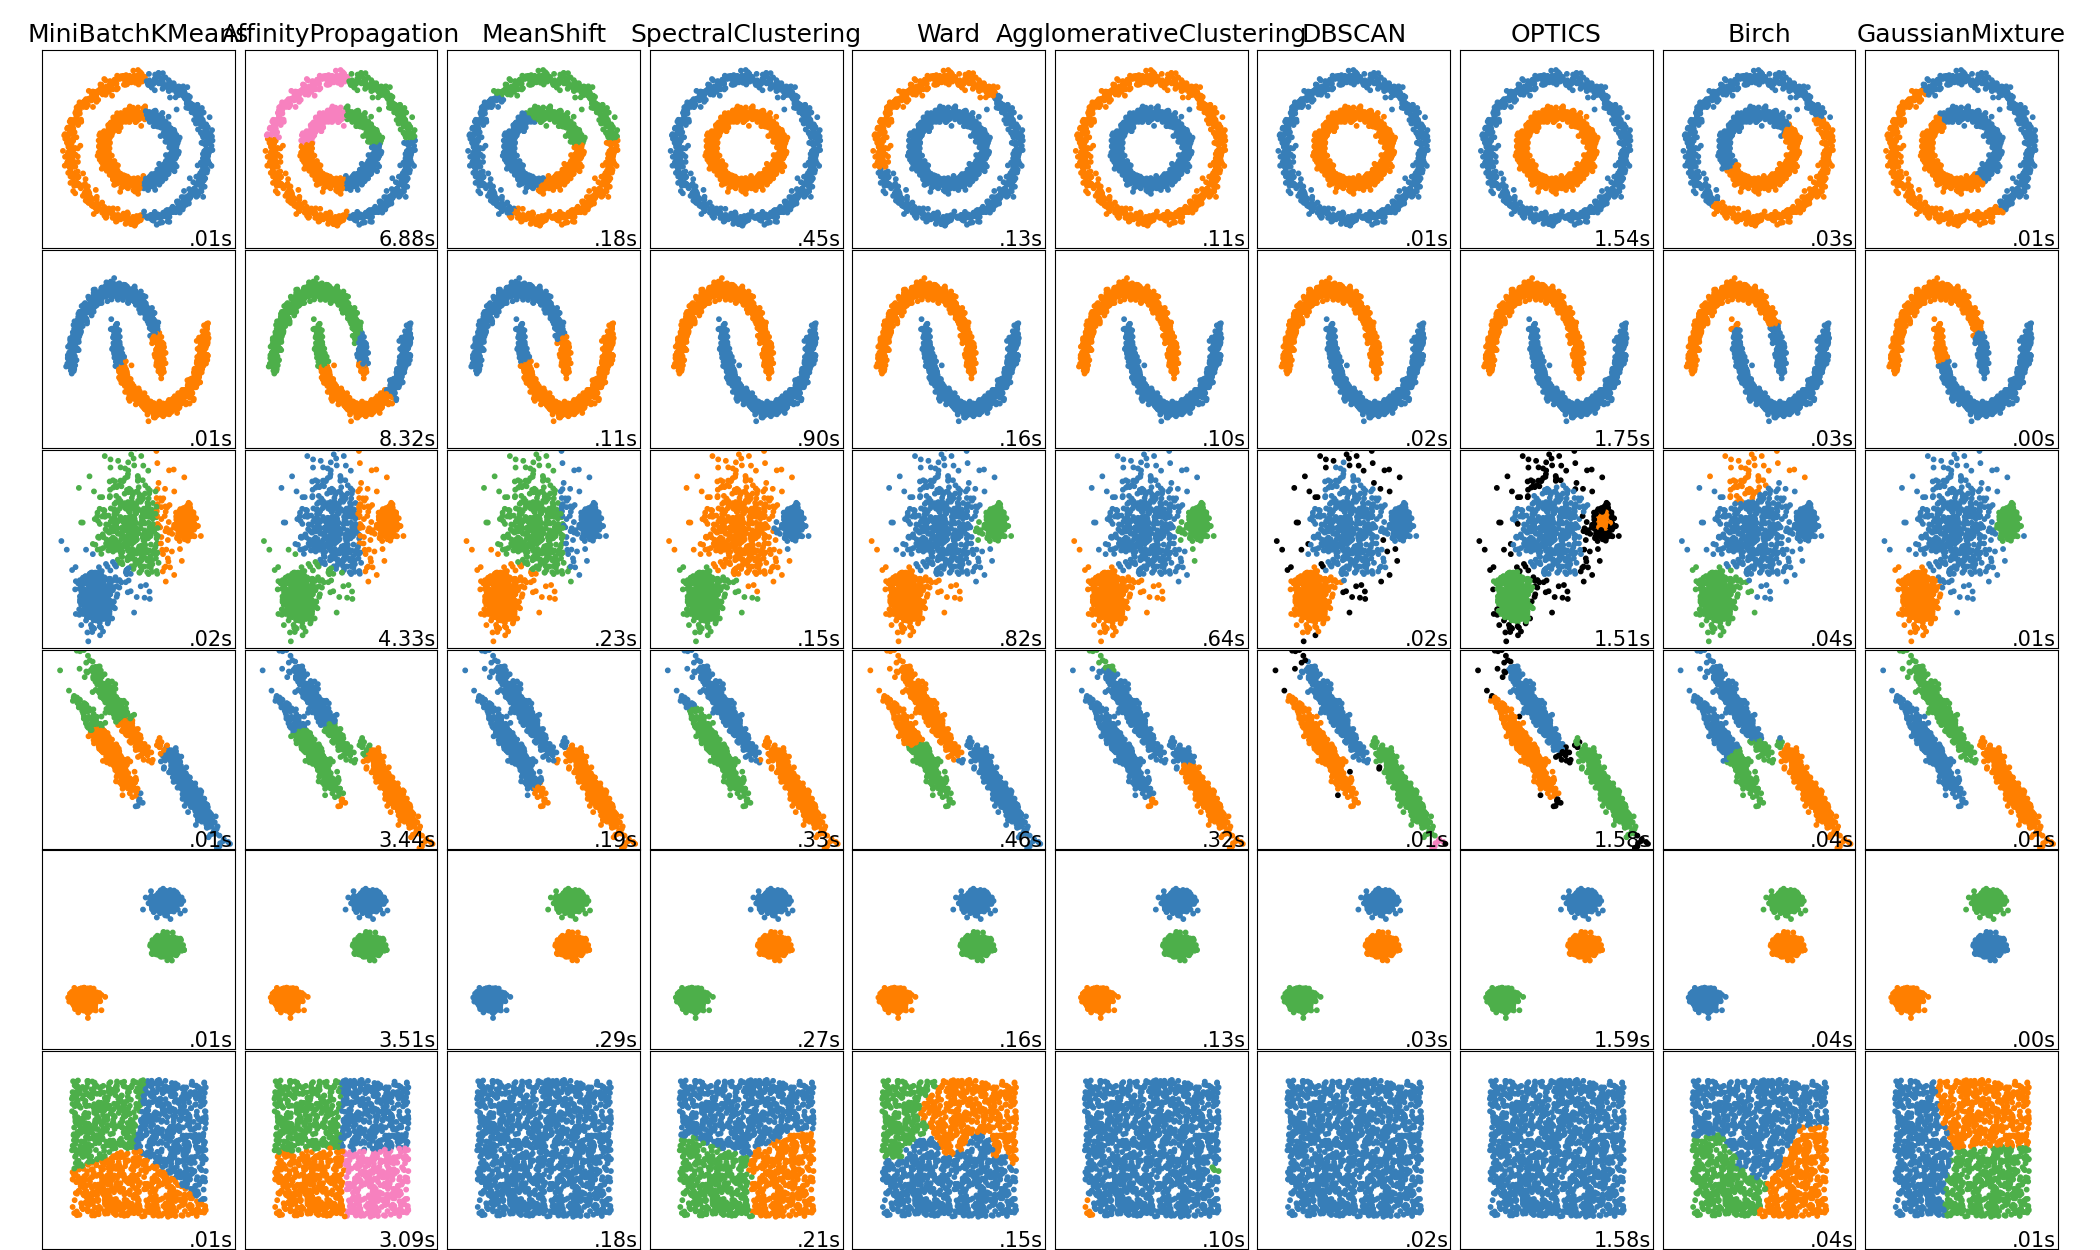

### 4.5.1 Application of Clustering with Sklearn

As an illustration of clusering, I will cluster the listings based on their geographical location. Suppose that we do not want to compare all of downtown or all of Santa Monica, but we only want to identify those that are close together. Luckily, we have latitute and longitude so we can create clusters based on that. 

In [ ]:
workingdata_below1000.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,log_price,Santa Monica,Santa Monica Price
16,11877,Le petit bungalow private entrance + bikes in VB,30484,Pascalou,City of Los Angeles,Venice,33.99753,-118.47226,Entire home/apt,70,30,45,2019-11-12,0.40,2,6,4.248495,0,0
20,14107,"ARCHITECTURAL GEM! BIKE, STROLL CANALS TO BEAC...",55422,Jane,City of Los Angeles,Venice,33.99025,-118.45374,Entire home/apt,425,31,30,2018-07-25,0.24,1,365,6.052089,0,0
25,18041,Bohemian home w/detached Studio & Rooftop Jacuzzi,69546,Lisa,City of Los Angeles,Venice,33.99179,-118.45056,Entire home/apt,282,30,3,2020-08-27,0.24,2,88,5.641907,0,0
27,20585,"Private Studio, 6 Doors to Beach",77857,Barbara,City of Los Angeles,Venice,33.98012,-118.46490,Entire home/apt,124,3,484,2020-10-04,3.75,1,51,4.820282,0,0
32,23925,Cactus Flower - Modernist Solar Guesthouse wit...,95543,Ecoboutiquehomes,City of Los Angeles,Venice,34.00416,-118.46602,Entire home/apt,297,3,119,2020-10-18,1.74,7,113,5.693732,0,0


In [ ]:
# First lets import the key libraries that we need # 

from sklearn.cluster import KMeans

You can look up the documentation for specific functions to understand how they function (ie. https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) 

In [ ]:
# We run the kmeans command and save the results into 

latitude_data = workingdata_below1000[['latitude', 'longitude']]

clusters = KMeans(n_clusters=10).fit(latitude_data)


In [ ]:
# To have kmeans provide us with a grouping of our data, we can ask kmeans to predict the groups #
# The output is a list of clusters for each observation (listing) in our data #

clusters.predict(latitude_data)

array([9, 6, 6, ..., 5, 5, 5], dtype=int32)

In [ ]:
# These are numerical data representing different groups (each number coresponds to a cluster). 

# We can add this to our data as follows. 

workingdata_below1000['Geographical Cluster'] = clusters.predict(latitude_data)

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


In [ ]:
# To see the output (Scroll right to see the newest variables )# 


workingdata_below1000.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,log_price,Santa Monica,Santa Monica Price,Geographical Cluster
16,11877,Le petit bungalow private entrance + bikes in VB,30484,Pascalou,City of Los Angeles,Venice,33.99753,-118.47226,Entire home/apt,70,30,45,2019-11-12,0.40,2,6,4.248495,0,0,9
20,14107,"ARCHITECTURAL GEM! BIKE, STROLL CANALS TO BEAC...",55422,Jane,City of Los Angeles,Venice,33.99025,-118.45374,Entire home/apt,425,31,30,2018-07-25,0.24,1,365,6.052089,0,0,6
25,18041,Bohemian home w/detached Studio & Rooftop Jacuzzi,69546,Lisa,City of Los Angeles,Venice,33.99179,-118.45056,Entire home/apt,282,30,3,2020-08-27,0.24,2,88,5.641907,0,0,6
27,20585,"Private Studio, 6 Doors to Beach",77857,Barbara,City of Los Angeles,Venice,33.98012,-118.46490,Entire home/apt,124,3,484,2020-10-04,3.75,1,51,4.820282,0,0,0
32,23925,Cactus Flower - Modernist Solar Guesthouse wit...,95543,Ecoboutiquehomes,City of Los Angeles,Venice,34.00416,-118.46602,Entire home/apt,297,3,119,2020-10-18,1.74,7,113,5.693732,0,0,3


# Next Steps

---- 

The objective of this workshop was to introduce you to how statistical modeling tools can be used in python. I focused primarily on regression as that is the most common use case. However, as the last section shows, you can perform a variety of other tasks such as clustering, prediction, etc. with python. 



*   If your primary goal is to just understand what can be done with python, but you are not familar with these other methods, I suggest focusing on the linear regression examples above. 

*   If you are familar with other methods (Clustering, PCA, SVM, etc.) and would like to implement them, I would suggest looking up the technique you would like to use in the sklearn documentation (https://scikit-learn.org/stable/modules/classes.html) and working through the examples. 

*   If there is an application from annother class that you would like me to cover in Python, let me know and I will try to cover it in the next in person session. 
